WEEK 2 — Topic Modeling & Department Categorization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

print("Libraries Imported Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Libraries Imported Successfully


In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [ ]:
df = pd.read_csv('cleaned_complaints.csv')

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully
Shape: (358057, 6)


,Complaint Type,Descriptor,Agency Name,Resolution Description,complaint_text,cleaned_text
0,Noise - Street/Sidewalk,Loud Music/Party,New York City Police Department,The Police Department responded and upon arriv...,Noise - Street/Sidewalk Loud Music/Party,noise street sidewalk loud music party
1,Blocked Driveway,No Access,New York City Police Department,The Police Department responded to the complai...,Blocked Driveway No Access,blocked driveway access
2,Blocked Driveway,No Access,New York City Police Department,The Police Department responded and upon arriv...,Blocked Driveway No Access,blocked driveway access
3,Illegal Parking,Commercial Overnight Parking,New York City Police Department,The Police Department responded to the complai...,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking
4,Illegal Parking,Blocked Sidewalk,New York City Police Department,The Police Department responded and upon arriv...,Illegal Parking Blocked Sidewalk,illegal parking blocked sidewalk


In [ ]:
complaint_counts = df['Complaint Type'].value_counts()
print(complaint_counts)

Complaint Type
Blocked Driveway            100881
Illegal Parking              92679
Noise - Street/Sidewalk      51692
Noise - Commercial           44109
Derelict Vehicle             21661
Noise - Vehicle              19352
Animal Abuse                 10541
Traffic                       5198
Vending                       4192
Noise - Park                  4109
Drinking                      1409
Noise - House of Worship      1070
Posting Advertisement          681
Disorderly Youth               315
Graffiti                       157
Agency Issues                    8
Ferry Complaint                  2
Animal in a Park                 1
Name: count, dtype: int64


In [ ]:
valid_types = complaint_counts[complaint_counts >= 100].index
df = df[df['Complaint Type'].isin(valid_types)]

print("Filtered Shape:", df.shape)
print("\nFinal Complaint Type counts:")
print(df['Complaint Type'].value_counts())

Filtered Shape: (358046, 6)

Final Complaint Type counts:
Complaint Type
Blocked Driveway            100881
Illegal Parking              92679
Noise - Street/Sidewalk      51692
Noise - Commercial           44109
Derelict Vehicle             21661
Noise - Vehicle              19352
Animal Abuse                 10541
Traffic                       5198
Vending                       4192
Noise - Park                  4109
Drinking                      1409
Noise - House of Worship      1070
Posting Advertisement          681
Disorderly Youth               315
Graffiti                       157
Name: count, dtype: int64


In [ ]:
print("Class Distribution (Proportions):")
print(df['Complaint Type'].value_counts(normalize=True).round(4) * 100)

print("\nObservation: Some complaint types (e.g., Disorderly Youth, Graffiti, Drinking)")
print("have significantly fewer samples than others (e.g., Blocked Driveway, Illegal Parking).")
print("This class imbalance means the model may perform worse on minority classes.")
print("Macro F1-score (used later) accounts for this by weighting all classes equally,")
print("rather than letting majority classes dominate the evaluation.")

Class Distribution (Proportions):
Complaint Type
Blocked Driveway            28.18
Illegal Parking             25.88
Noise - Street/Sidewalk     14.44
Noise - Commercial          12.32
Derelict Vehicle             6.05
Noise - Vehicle              5.40
Animal Abuse                 2.94
Traffic                      1.45
Vending                      1.17
Noise - Park                 1.15
Drinking                     0.39
Noise - House of Worship     0.30
Posting Advertisement        0.19
Disorderly Youth             0.09
Graffiti                     0.04
Name: proportion, dtype: float64

Observation: Some complaint types (e.g., Disorderly Youth, Graffiti, Drinking)
have significantly fewer samples than others (e.g., Blocked Driveway, Illegal Parking).
This class imbalance means the model may perform worse on minority classes.
Macro F1-score (used later) accounts for this by weighting all classes equally,
rather than letting majority classes dominate the evaluation.


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

df['final_text'] = df['Descriptor'].apply(clean_text)

print("Text Cleaning Completed")
df[['Descriptor', 'final_text', 'Complaint Type']].head(10)

Text Cleaning Completed


,Descriptor,final_text,Complaint Type
0,Loud Music/Party,loud music party,Noise - Street/Sidewalk
1,No Access,access,Blocked Driveway
2,No Access,access,Blocked Driveway
3,Commercial Overnight Parking,commercial overnight parking,Illegal Parking
4,Blocked Sidewalk,blocked sidewalk,Illegal Parking
5,Posted Parking Sign Violation,posted parking sign violation,Illegal Parking
6,Blocked Hydrant,blocked hydrant,Illegal Parking
7,No Access,access,Blocked Driveway
8,Posted Parking Sign Violation,posted parking sign violation,Illegal Parking
9,No Access,access,Blocked Driveway


In [ ]:
df = df[df['final_text'].str.strip() != '']

print("Shape after removing empty text rows:", df.shape)

Shape after removing empty text rows: (358046, 7)


In [ ]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['final_text'])
y = df['Complaint Type']

print("TF-IDF Shape:", X.shape)
print("Number of unique complaint types:", y.nunique())

TF-IDF Shape: (358046, 67)
Number of unique complaint types: 15


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 286436
Testing samples: 71610


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes (Baseline) Trained Successfully")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Macro F1-Score:", f1_score(y_test, y_pred_nb, average='macro'))

Naive Bayes (Baseline) Trained Successfully
Accuracy: 0.8727133081971792
Macro F1-Score: 0.7410196190102786


In [ ]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression (with class balancing) Trained Successfully")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Macro F1-Score:", f1_score(y_test, y_pred_lr, average='macro'))

Logistic Regression (with class balancing) Trained Successfully
Accuracy: 0.7797653958944282
Macro F1-Score: 0.7754127827690686


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest (with class balancing) Trained Successfully")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1-Score:", f1_score(y_test, y_pred_rf, average='macro'))

Random Forest (with class balancing) Trained Successfully
Accuracy: 0.7797653958944282
Macro F1-Score: 0.7754127827690686


In [ ]:
cv_scores_lr = cross_val_score(log_reg, X, y, cv=5, scoring='accuracy')

print("Logistic Regression Cross-Validation Scores:", cv_scores_lr)
print("Average CV Accuracy:", cv_scores_lr.mean())
print("Standard Deviation:", cv_scores_lr.std())

Logistic Regression Cross-Validation Scores: [0.79117442 0.77062939 0.76859054 0.77262635 0.79076652]
Average CV Accuracy: 0.7787574434095799
Standard Deviation: 0.010054061561323095


MODEL COMPARISON
Model                    Accuracy       Macro F1-Score 
------------------------------------------------------------
Naive Bayes (Baseline)   0.8727         0.7410         
Logistic Regression      0.7798         0.7754         
Random Forest            0.7798         0.7754         


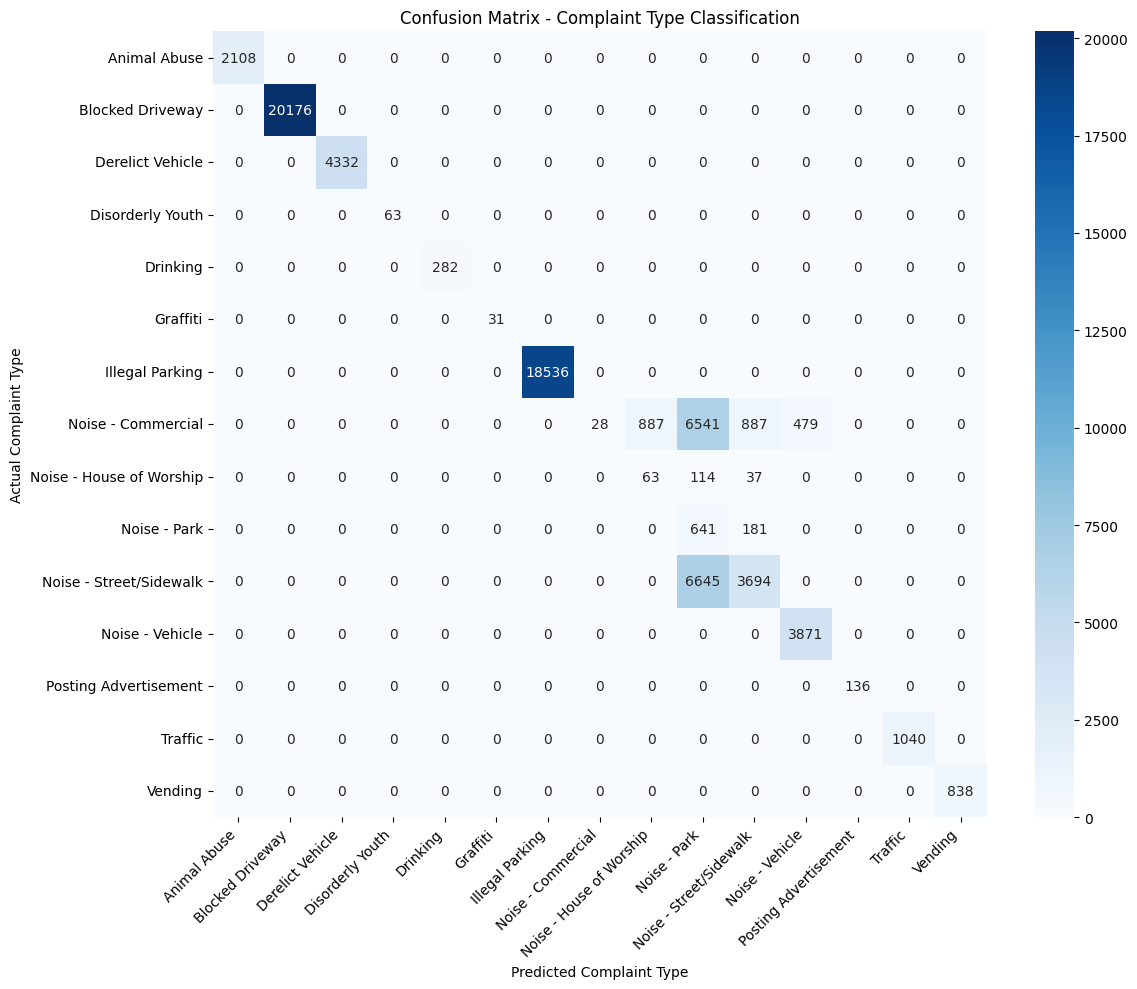

In [ ]:
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<25}{'Accuracy':<15}{'Macro F1-Score':<15}")
print("-" * 60)
print(f"{'Naive Bayes (Baseline)':<25}{accuracy_score(y_test, y_pred_nb):<15.4f}{f1_score(y_test, y_pred_nb, average='macro'):<15.4f}")
print(f"{'Logistic Regression':<25}{accuracy_score(y_test, y_pred_lr):<15.4f}{f1_score(y_test, y_pred_lr, average='macro'):<15.4f}")
print(f"{'Random Forest':<25}{accuracy_score(y_test, y_pred_rf):<15.4f}{f1_score(y_test, y_pred_rf, average='macro'):<15.4f}")

# Choose the better performing model based on Macro F1
final_model = log_reg
y_pred_final = y_pred_lr

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final, labels=final_model.classes_)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_model.classes_,
            yticklabels=final_model.classes_)
plt.title('Confusion Matrix - Complaint Type Classification')
plt.xlabel('Predicted Complaint Type')
plt.ylabel('Actual Complaint Type')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("CLASSIFICATION REPORT - Complaint Type Categorization")
print("=" * 60)
print(classification_report(y_test, y_pred_final))

CLASSIFICATION REPORT - Complaint Type Categorization
                          precision    recall  f1-score   support

            Animal Abuse       1.00      1.00      1.00      2108
        Blocked Driveway       1.00      1.00      1.00     20176
        Derelict Vehicle       1.00      1.00      1.00      4332
        Disorderly Youth       1.00      1.00      1.00        63
                Drinking       1.00      1.00      1.00       282
                Graffiti       1.00      1.00      1.00        31
         Illegal Parking       1.00      1.00      1.00     18536
      Noise - Commercial       1.00      0.00      0.01      8822
Noise - House of Worship       0.07      0.29      0.11       214
            Noise - Park       0.05      0.78      0.09       822
 Noise - Street/Sidewalk       0.77      0.36      0.49     10339
         Noise - Vehicle       0.89      1.00      0.94      3871
   Posting Advertisement       1.00      1.00      1.00       136
                 Traf

In [ ]:
import joblib

joblib.dump(final_model, '/content/complaint_classifier_model.pkl')
joblib.dump(tfidf, '/content/tfidf_vectorizer.pkl')

print("Model and Vectorizer Saved Successfully")

Model and Vectorizer Saved Successfully


In [ ]:
df.to_csv('/content/week2_processed_complaints.csv', index=False)

print("Dataset saved for Week 3")
print("Final shape:", df.shape)

Dataset saved for Week 3
Final shape: (358046, 7)


In [ ]:
print("=" * 60)
print("WEEK 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nTASKS COMPLETED:")
print("1. Identified and fixed label leakage issue (Complaint Type was inside input text)")
print("2. Filtered out complaint types with fewer than 100 samples")
print("3. Printed class distribution proportions to highlight imbalance")
print("4. Re-cleaned text using ONLY the Descriptor column")
print("5. Text converted to numerical vectors using TF-IDF")
print("   - Vocabulary size:", X.shape[1], "features")
print("6. Data split into Train (80%) and Test (20%) using stratified sampling")
print("7. Naive Bayes (baseline) trained -> Accuracy:", round(accuracy_score(y_test, y_pred_nb), 4))
print("8. Logistic Regression trained -> Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("9. Random Forest trained -> Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("10. 5-Fold Cross-Validation performed")
print("    - Average CV Accuracy:", round(cv_scores_lr.mean(), 4))
print("11. Confusion Matrix and Classification Report generated")
print("12. Final model and TF-IDF vectorizer saved (excluded from GitHub via .gitignore)")

print("\nNEXT STEP: Week 3 - Sentiment Analysis and Urgency Scoring")
print("=" * 60)

WEEK 2 COMPLETED SUCCESSFULLY

TASKS COMPLETED:
1. Identified and fixed label leakage issue (Complaint Type was inside input text)
2. Filtered out complaint types with fewer than 100 samples
3. Printed class distribution proportions to highlight imbalance
4. Re-cleaned text using ONLY the Descriptor column
5. Text converted to numerical vectors using TF-IDF
   - Vocabulary size: 67 features
6. Data split into Train (80%) and Test (20%) using stratified sampling
7. Naive Bayes (baseline) trained -> Accuracy: 0.8727
8. Logistic Regression trained -> Accuracy: 0.7798
9. Random Forest trained -> Accuracy: 0.7798
10. 5-Fold Cross-Validation performed
    - Average CV Accuracy: 0.7788
11. Confusion Matrix and Classification Report generated
12. Final model and TF-IDF vectorizer saved (excluded from GitHub via .gitignore)

NEXT STEP: Week 3 - Sentiment Analysis and Urgency Scoring
